# Estudo do Uso de Contadores Inteligentes

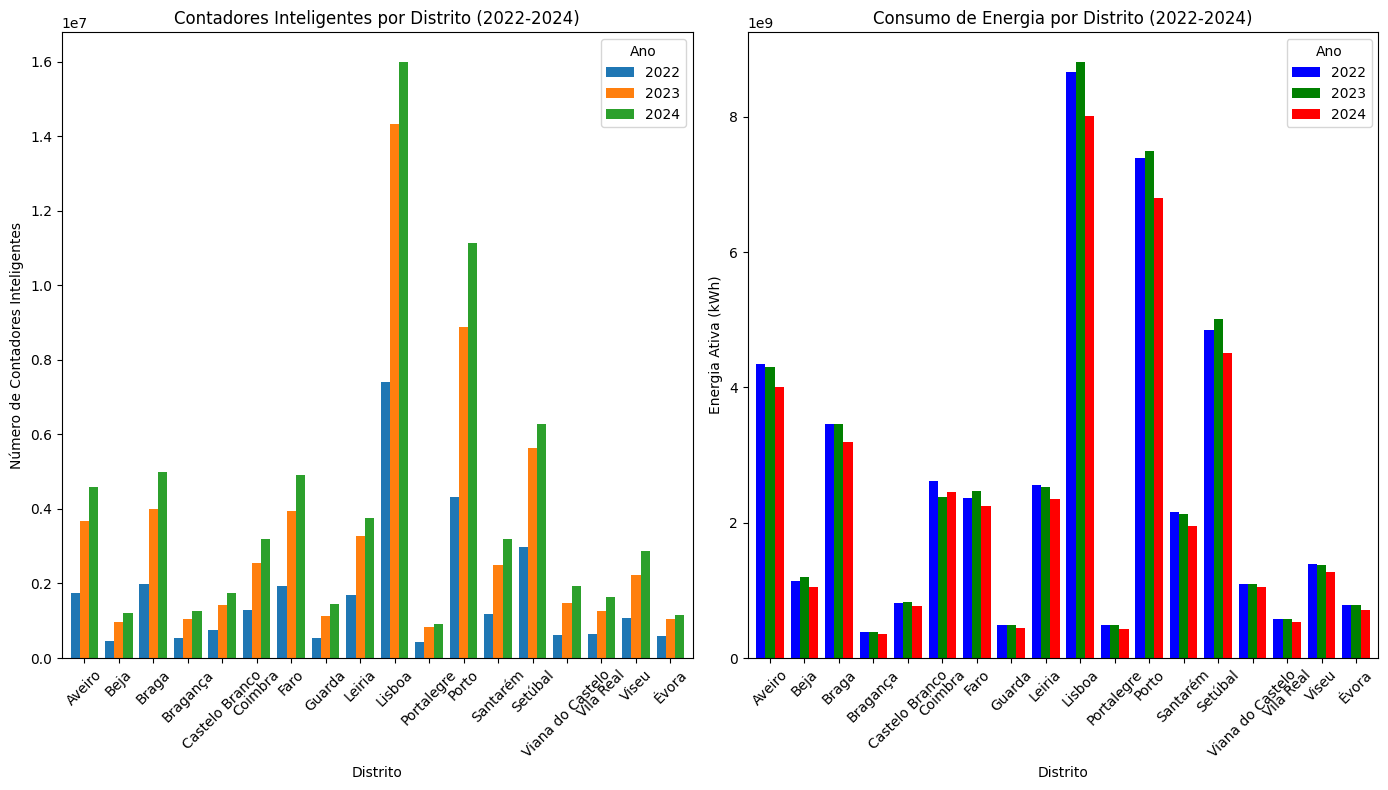

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV de contadores inteligentes
dados_contadores = pd.read_csv('./data/contadores.csv', sep=';')

# Filtrar apenas os contadores inteligentes
dados_contadores_inteligentes = dados_contadores[dados_contadores['Inclui contador inteligente'] == 'Sim']

# Filtrar os dados para os anos de 2022 a 2024
dados_contadores_inteligentes = dados_contadores_inteligentes[dados_contadores_inteligentes['Ano'].isin([2022, 2023, 2024])]

# Agrupar por Distrito e Ano, somando o número de CPE's (Número de instalações de contadores inteligentes)
tabela_contadores_inteligentes = dados_contadores_inteligentes.groupby(['Distrito', 'Ano'])['Número de CPE\'s'].sum().reset_index()

# Carregar o arquivo CSV de consumos mensais
dados_consumos = pd.read_csv('./data/consumos-mensais-por-distrito.csv', sep=';')

# Converter a coluna 'Data' para o formato datetime
dados_consumos['Data'] = pd.to_datetime(dados_consumos['Data'], errors='coerce')

# Filtrar os dados para os anos de 2022 a 2024
dados_consumos = dados_consumos[dados_consumos['Ano'].isin([2022, 2023, 2024])]

# Agrupar por Distrito e Ano, somando o consumo de energia (Energia Ativa em kWh)
tabela_consumo_anual = dados_consumos.groupby(['Distrito', 'Ano'])['Energia Ativa (kWh)'].sum().reset_index()

# Agora vamos combinar as duas tabelas (contadores inteligentes e consumo anual) com base no Distrito e Ano
tabela_combinada = pd.merge(tabela_contadores_inteligentes, tabela_consumo_anual, on=['Distrito', 'Ano'])

# Plotar os gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Gráfico de barras para contadores inteligentes
tabela_contadores_inteligentes_pivot = tabela_contadores_inteligentes.pivot(index='Distrito', columns='Ano', values="Número de CPE\'s").fillna(0)
tabela_contadores_inteligentes_pivot.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Contadores Inteligentes por Distrito (2022-2024)')
axes[0].set_xlabel('Distrito')
axes[0].set_ylabel('Número de Contadores Inteligentes')
axes[0].set_xticklabels(tabela_contadores_inteligentes_pivot.index, rotation=45)

# Gráfico de barras para consumo de energia
tabela_consumo_anual_pivot = tabela_combinada.pivot(index='Distrito', columns='Ano', values='Energia Ativa (kWh)').fillna(0)
tabela_consumo_anual_pivot.plot(kind='bar', ax=axes[1], width=0.8, color=['blue', 'green', 'red'])
axes[1].set_title('Consumo de Energia por Distrito (2022-2024)')
axes[1].set_xlabel('Distrito')
axes[1].set_ylabel('Energia Ativa (kWh)')
axes[1].set_xticklabels(tabela_consumo_anual_pivot.index, rotation=45)

# Ajustar layout
plt.tight_layout()
plt.show()


Em todos os casos o aumento do número de contadores inteligentes promoveu à diminuição do consumo de energia